In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(
    "mymoviedb.csv",
    engine="python"
)

In [7]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [8]:
df.shape

(9837, 9)

In [9]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [11]:
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [14]:
df['Release_Date'].dtype

dtype('O')

In [16]:
df['Release_Date'] = pd.to_datetime(
    df['Release_Date'],
    errors='coerce'
)


In [17]:
df['Release_Date'].dtype

dtype('<M8[ns]')

In [18]:
df['Release_Year'] = df['Release_Date'].dt.year

In [19]:
movies_per_year = df['Release_Year'].value_counts()

movies_per_year

,count
Release_Year,
2021.0,714
2018.0,530
2017.0,510
2019.0,500
2016.0,470
...,...
1925.0,1
1902.0,1
1920.0,1


In [20]:
movies_per_year.idxmax()

np.float64(2021.0)

In [21]:
movies_per_year.max()

714

In [22]:
movies_per_year = df['Release_Year'].value_counts()

In [23]:
movies_per_year.idxmax()

np.float64(2021.0)

In [24]:
movies_per_year.idxmax()

np.float64(2021.0)

In [25]:
movies_per_year.max()

714

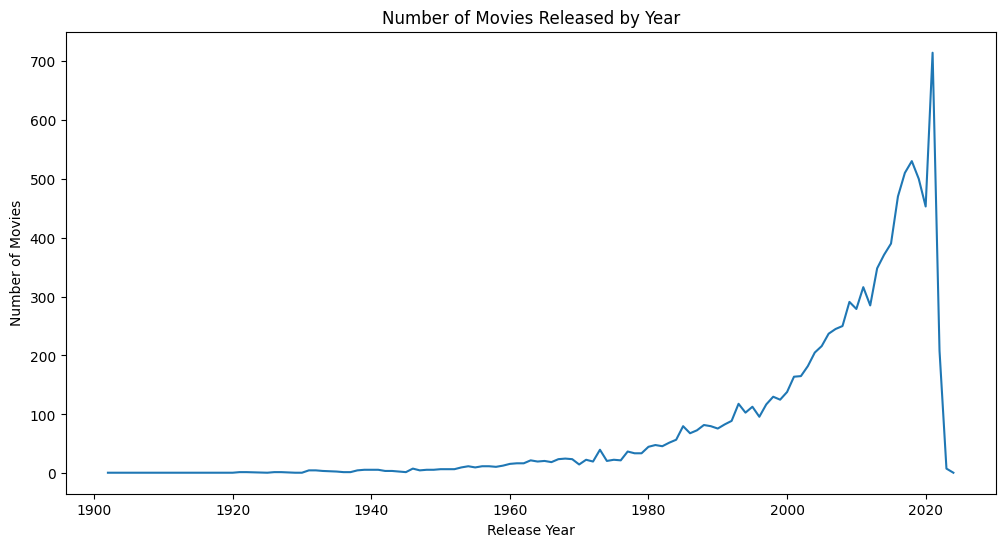

In [26]:
plt.figure(figsize=(12, 6))

movies_per_year.sort_index().plot()

plt.title("Number of Movies Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

In [27]:
df['Genre'].head(10)

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"
5,"Action, Crime, Thriller"
6,"Horror, Mystery, Thriller"
7,Thriller
8,"Action, Crime, Fantasy"
9,Science Fiction


In [28]:
genre_data = df['Genre'].dropna().str.split(', ')

In [29]:
genre_data.head()

,Genre
0,"[Action, Adventure, Science Fiction]"
1,"[Crime, Mystery, Thriller]"
2,[Thriller]
3,"[Animation, Comedy, Family, Fantasy]"
4,"[Action, Adventure, Thriller, War]"


In [30]:
all_genres = genre_data.explode()

In [31]:
all_genres.head(20)

,Genre
0,Action
0,Adventure
0,Science Fiction
1,Crime
1,Mystery
1,Thriller
2,Thriller
3,Animation
3,Comedy
3,Family


In [32]:
genre_counts = all_genres.value_counts()

genre_counts.head(10)

,count
Genre,
Drama,3744
Comedy,3031
Action,2686
Thriller,2488
Adventure,1853
Romance,1476
Horror,1470
Animation,1438
Family,1414


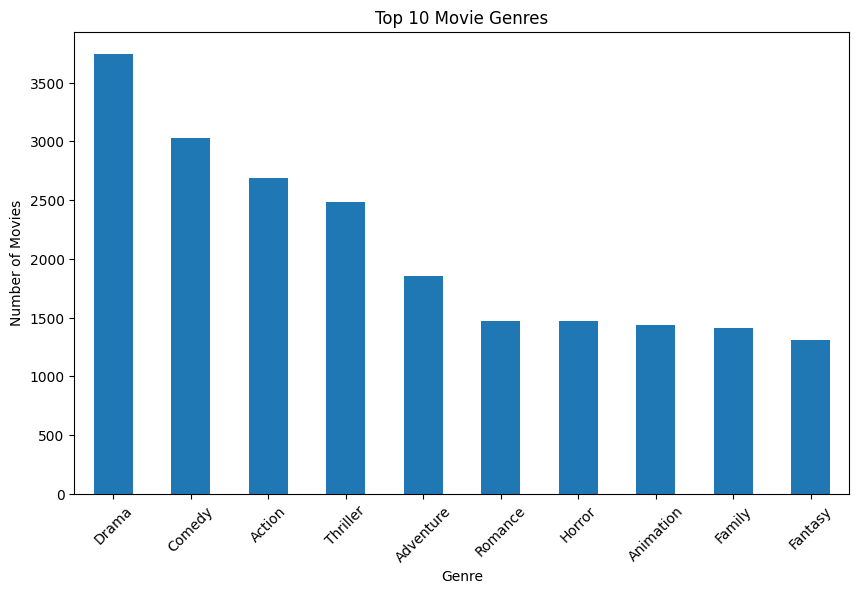

In [33]:
plt.figure(figsize=(10, 6))

genre_counts.head(10).plot(kind='bar')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

In [34]:
top_rated = df.sort_values(
    by='Vote_Average',
    ascending=False
)

In [35]:
top_rated[['Title', 'Vote_Average', 'Vote_Count']].head(10)

,Title,Vote_Average,Vote_Count
1115,61.328,Animation,en
7349,Franco Escamilla: Por La Anécdota,9.2,92
2335,Impossible Things,9.1,82
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1,27
2401,The Three Deaths of Marisela Escobedo,9.0,183
7411,My Sex Doll,9.0,4
6738,Mission «Sky»,9.0,34
7024,Sex School: Dorms of Desire,9.0,1
8657,Burn the Stage: The Movie,8.9,332
5079,"Ni tuyo, Ni mía",8.9,49


In [41]:
df['Vote_Count'] = pd.to_numeric(
    df['Vote_Count'],
    errors='coerce'
)

In [42]:
df['Vote_Count'].dtype

dtype('float64')

In [40]:
reliable_movies = df[df['Vote_Count'] >= 100]


In [43]:
df['Popularity'].dtype

dtype('float64')

In [44]:
most_popular = df.sort_values(
    by='Popularity',
    ascending=False
)

In [45]:
most_popular[
    ['Title', 'Popularity', 'Vote_Average', 'Vote_Count']
].head(10)

,Title,Popularity,Vote_Average,Vote_Count
0,Spider-Man: No Way Home,5083.954,8.3,8940.0
1,The Batman,3827.658,8.1,1151.0
2,No Exit,2618.087,6.3,122.0
3,Encanto,2402.201,7.7,5076.0
4,The King's Man,1895.511,7.0,1793.0
5,The Commando,1750.484,6.6,33.0
6,Scream,1675.161,6.8,821.0
7,Kimi,1601.782,6.3,206.0
8,Fistful of Vengeance,1594.013,5.3,114.0
9,Eternals,1537.406,7.2,4726.0


In [46]:
language_counts = df['Original_Language'].value_counts()

language_counts.head(10)

,count
Original_Language,
en,7569
ja,645
es,339
fr,292
ko,170
zh,129
it,123
cn,109
ru,83


In [47]:
df['Original_Language'].nunique()

44

In [48]:
language_counts = df['Original_Language'].value_counts()
language_counts.head(10)

,count
Original_Language,
en,7569
ja,645
es,339
fr,292
ko,170
zh,129
it,123
cn,109
ru,83


In [49]:
df['Original_Language'].nunique()

44

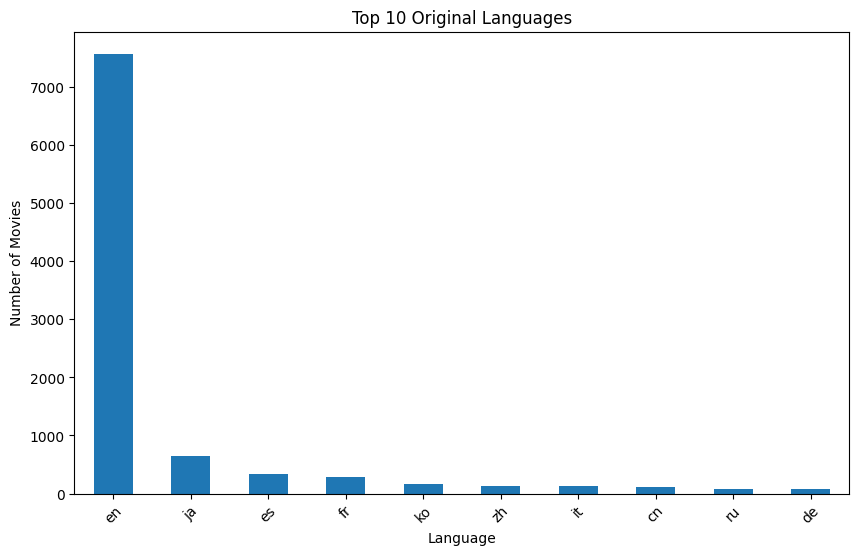

In [50]:
plt.figure(figsize=(10, 6))

language_counts.head(10).plot(kind='bar')

plt.title("Top 10 Original Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

In [53]:
df['Vote_Average'] = pd.to_numeric(
    df['Vote_Average'],
    errors='coerce'
)

In [54]:
average_rating = df['Vote_Average'].mean()

print("Average Movie Rating:", round(average_rating, 2))

Average Movie Rating: 6.44


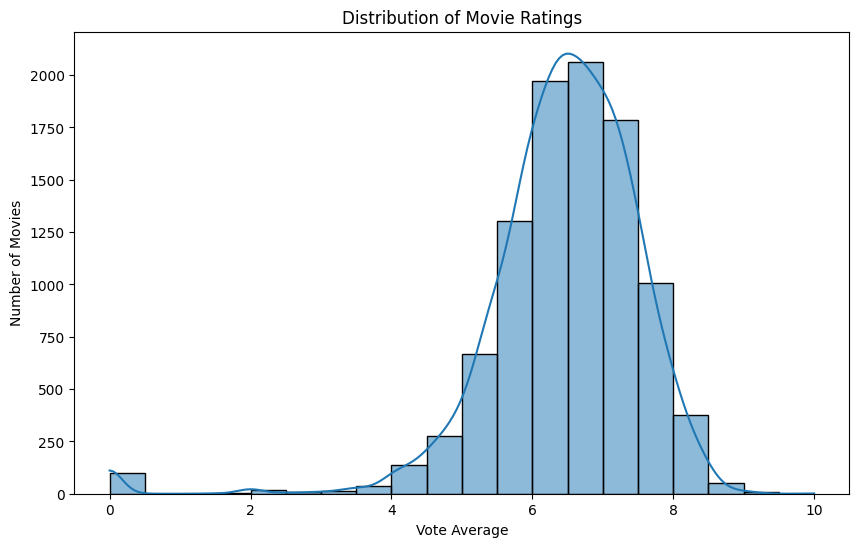

In [55]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Vote_Average'].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")

plt.show()

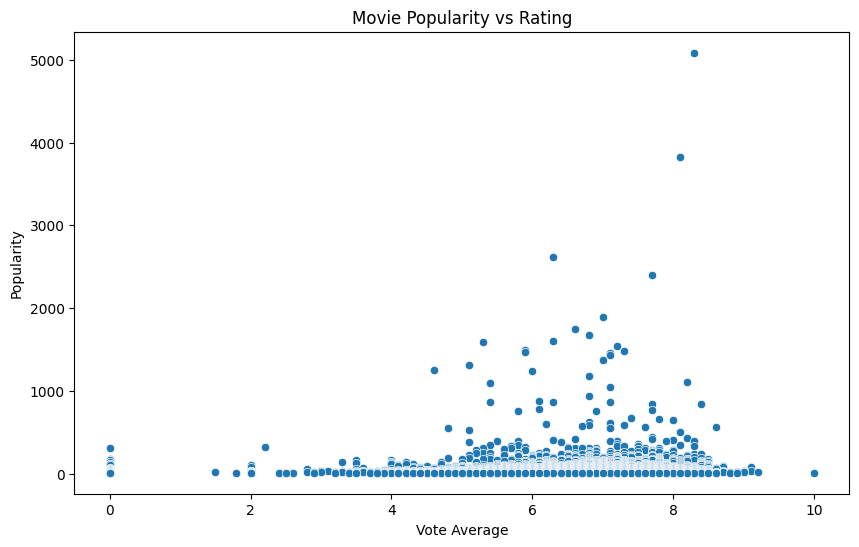

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Vote_Average',
    y='Popularity'
)

plt.title("Movie Popularity vs Rating")
plt.xlabel("Vote Average")
plt.ylabel("Popularity")

plt.show()

In [57]:
correlation = df['Popularity'].corr(df['Vote_Average'])

print("Correlation between Popularity and Rating:", round(correlation, 2))

Correlation between Popularity and Rating: 0.05


In [58]:
most_popular_movie = df.loc[df['Popularity'].idxmax()]

print("Title:", most_popular_movie['Title'])
print("Popularity:", most_popular_movie['Popularity'])
print("Rating:", most_popular_movie['Vote_Average'])
print("Votes:", most_popular_movie['Vote_Count'])

Title: Spider-Man: No Way Home
Popularity: 5083.954
Rating: 8.3
Votes: 8940.0


In [59]:
top_10_popular = df.sort_values(
    by='Popularity',
    ascending=False
).head(10)

top_10_popular[
    ['Title', 'Popularity', 'Vote_Average', 'Vote_Count']
]

,Title,Popularity,Vote_Average,Vote_Count
0,Spider-Man: No Way Home,5083.954,8.3,8940.0
1,The Batman,3827.658,8.1,1151.0
2,No Exit,2618.087,6.3,122.0
3,Encanto,2402.201,7.7,5076.0
4,The King's Man,1895.511,7.0,1793.0
5,The Commando,1750.484,6.6,33.0
6,Scream,1675.161,6.8,821.0
7,Kimi,1601.782,6.3,206.0
8,Fistful of Vengeance,1594.013,5.3,114.0
9,Eternals,1537.406,7.2,4726.0


In [60]:
top_10_rated = df.sort_values(
    by='Vote_Average',
    ascending=False
).head(10)

top_10_rated[
    ['Title', 'Vote_Average', 'Vote_Count']
]

,Title,Vote_Average,Vote_Count
9401,Kung Fu Master Huo Yuanjia,10.0,1.0
7349,Franco Escamilla: Por La Anécdota,9.2,92.0
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1,27.0
2335,Impossible Things,9.1,82.0
7411,My Sex Doll,9.0,4.0
6738,Mission «Sky»,9.0,34.0
7024,Sex School: Dorms of Desire,9.0,1.0
2401,The Three Deaths of Marisela Escobedo,9.0,183.0
7049,Bring the Soul: The Movie,8.9,323.0
5079,"Ni tuyo, Ni mía",8.9,49.0


In [61]:
reliable_movies = df[df['Vote_Count'] >= 100]

top_reliable_rated = reliable_movies.sort_values(
    by='Vote_Average',
    ascending=False
).head(10)

top_reliable_rated[
    ['Title', 'Vote_Average', 'Vote_Count']
]

,Title,Vote_Average,Vote_Count
2401,The Three Deaths of Marisela Escobedo,9.0,183.0
7049,Bring the Soul: The Movie,8.9,323.0
8657,Burn the Stage: The Movie,8.9,332.0
3662,Violet Evergarden: The Movie,8.7,195.0
4942,Green Snake,8.7,142.0
609,The Godfather,8.7,15614.0
657,The Shawshank Redemption,8.7,20911.0
3156,Dilwale Dulhania Le Jayenge,8.7,3474.0
4196,Gabriel's Inferno Part III,8.6,946.0
3883,"Josee, the Tiger and the Fish",8.6,192.0


In [62]:
genre_counts.head(10)

,count
Genre,
Drama,3744
Comedy,3031
Action,2686
Thriller,2488
Adventure,1853
Romance,1476
Horror,1470
Animation,1438
Family,1414


In [63]:
genre_df = df[['Genre', 'Vote_Average']].dropna()

genre_df['Genre'] = genre_df['Genre'].str.split(', ')

genre_df = genre_df.explode('Genre')

average_rating_by_genre = (
    genre_df.groupby('Genre')['Vote_Average']
    .mean()
    .sort_values(ascending=False)
)

average_rating_by_genre.head(10)

,Vote_Average
Genre,
History,6.965574
War,6.948701
Music,6.879322
Animation,6.846384
Western,6.754745
Drama,6.706143
Documentary,6.663721
Family,6.581047
Romance,6.560772


In [64]:
movies_per_year = df['Release_Year'].value_counts().sort_index()

movies_per_year


,count
Release_Year,
1902.0,1
1920.0,1
1921.0,2
1922.0,2
1925.0,1
...,...
2020.0,453
2021.0,714
2022.0,208


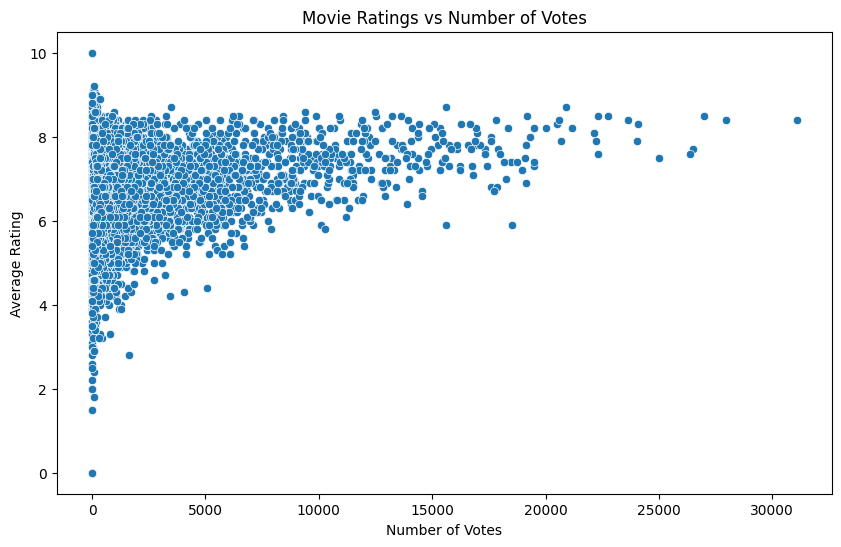

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Vote_Count',
    y='Vote_Average'
)

plt.title("Movie Ratings vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")

plt.show()

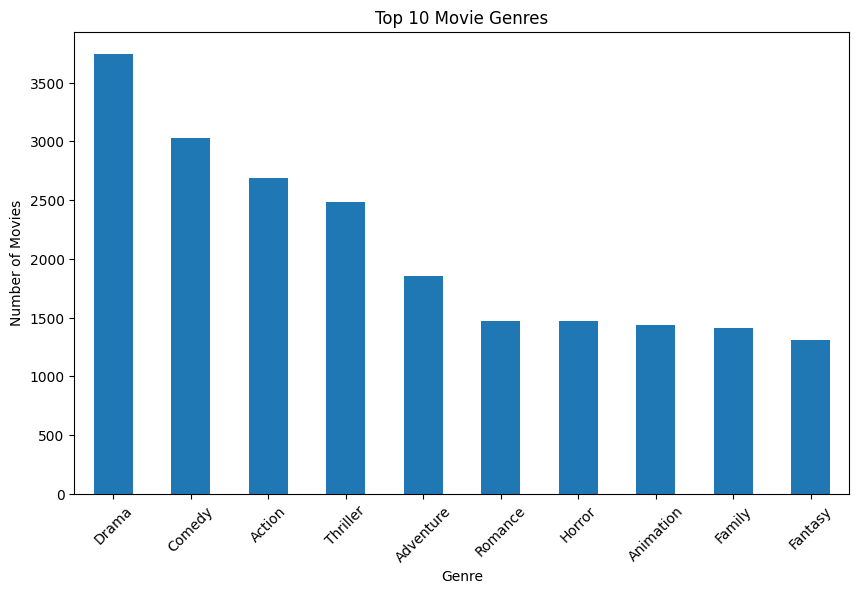

In [66]:
plt.figure(figsize=(10, 6))

genre_counts.head(10).plot(kind='bar')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

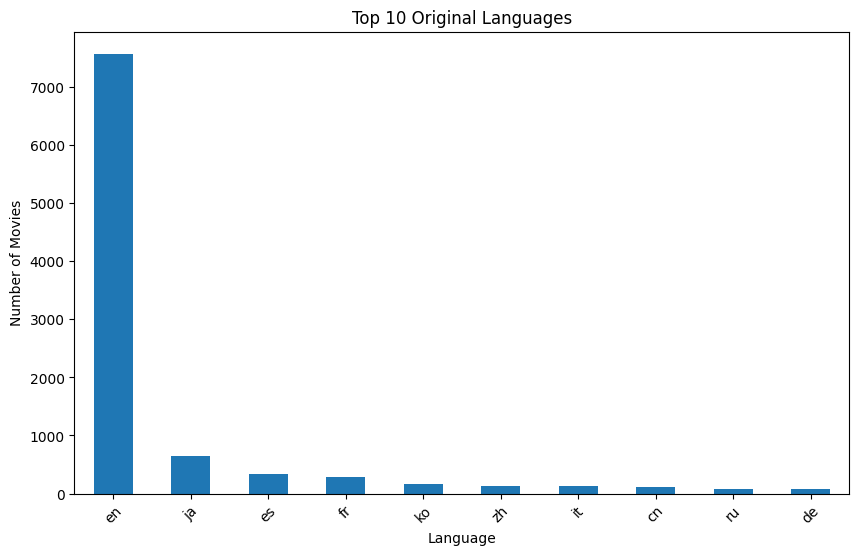

In [67]:
plt.figure(figsize=(10, 6))

language_counts.head(10).plot(kind='bar')

plt.title("Top 10 Original Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

In [68]:
print("Total Movies:", df['Title'].nunique())
print("Average Rating:", round(df['Vote_Average'].mean(), 2))
print("Average Popularity:", round(df['Popularity'].mean(), 2))
print("Total Genres:", len(genre_counts))
print("Total Languages:", df['Original_Language'].nunique())
print("Most Common Genre:", genre_counts.idxmax())
print("Most Common Language:", language_counts.idxmax())
print("Highest Rated Movie:", df.loc[df['Vote_Average'].idxmax(), 'Title'])
print("Most Popular Movie:", df.loc[df['Popularity'].idxmax(), 'Title'])

Total Movies: 9514
Average Rating: 6.44
Average Popularity: 40.32
Total Genres: 19
Total Languages: 44
Most Common Genre: Drama
Most Common Language: en
Highest Rated Movie: Kung Fu Master Huo Yuanjia
Most Popular Movie: Spider-Man: No Way Home


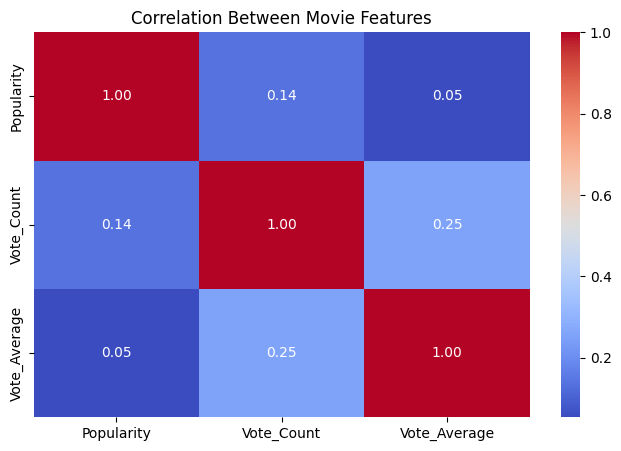

In [69]:
plt.figure(figsize=(8, 5))

correlation_data = df[
    ['Popularity', 'Vote_Count', 'Vote_Average']
].corr()

sns.heatmap(
    correlation_data,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Movie Features")
plt.show()

In [70]:
df.to_csv("netflix_movies_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [71]:
df.shape

(9837, 10)

In [73]:
df.shape

(9837, 10)

In [74]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021.0
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022.0
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022.0
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021.0
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021.0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Overview           9828 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
 9   Release_Year       9827 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 768.6+ KB


In [76]:
df.isnull().sum()

,0
Release_Date,10
Title,9
Overview,9
Popularity,10
Vote_Count,11
Vote_Average,11
Original_Language,10
Genre,11
Poster_Url,11
Release_Year,10


In [77]:
df.duplicated().sum()

np.int64(8)

In [78]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average,Release_Year
count,9827,9827.000000,9826.000000,9826.000000,9827.000000
mean,2006-09-23 11:05:51.317797888,40.320570,1392.943721,6.439467,2006.203623
min,1902-04-17 00:00:00,7.100000,0.000000,0.000000,1902.000000
25%,2000-10-18 00:00:00,16.127500,146.000000,5.900000,2000.000000
50%,2011-09-13 00:00:00,21.191000,444.000000,6.500000,2011.000000
75%,2017-11-22 00:00:00,35.174500,1376.000000,7.100000,2017.000000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000,2024.000000
std,NaN,108.874308,2611.303856,1.129797,15.685554


In [79]:
df['Genre'].value_counts().head(10)

,count
Genre,
Drama,466
Comedy,403
"Drama, Romance",248
Horror,238
"Horror, Thriller",199
"Comedy, Romance",196
Documentary,139
"Comedy, Drama",137
"Action, Thriller",125


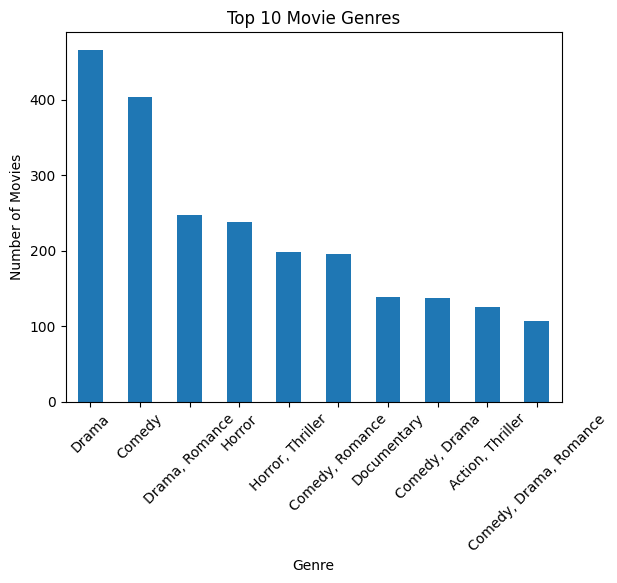

In [80]:
import matplotlib.pyplot as plt

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [81]:
df['Genre'].value_counts().head(10)

,count
Genre,
Drama,466
Comedy,403
"Drama, Romance",248
Horror,238
"Horror, Thriller",199
"Comedy, Romance",196
Documentary,139
"Comedy, Drama",137
"Action, Thriller",125


In [82]:
df['Vote_Average'].head()

,Vote_Average
0,8.3
1,8.1
2,6.3
3,7.7
4,7.0


In [83]:
df['Vote_Average'].dtype

dtype('float64')

In [84]:
average_rating = df['Vote_Average'].mean()

print("Average Movie Rating:", average_rating)

Average Movie Rating: 6.4394667209444325


In [85]:
df[['Title', 'Vote_Average']].sort_values(
    by='Vote_Average',
    ascending=False
).head(10)

,Title,Vote_Average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2335,Impossible Things,9.1
7411,My Sex Doll,9.0
6738,Mission «Sky»,9.0
7024,Sex School: Dorms of Desire,9.0
2401,The Three Deaths of Marisela Escobedo,9.0
7049,Bring the Soul: The Movie,8.9
5079,"Ni tuyo, Ni mía",8.9


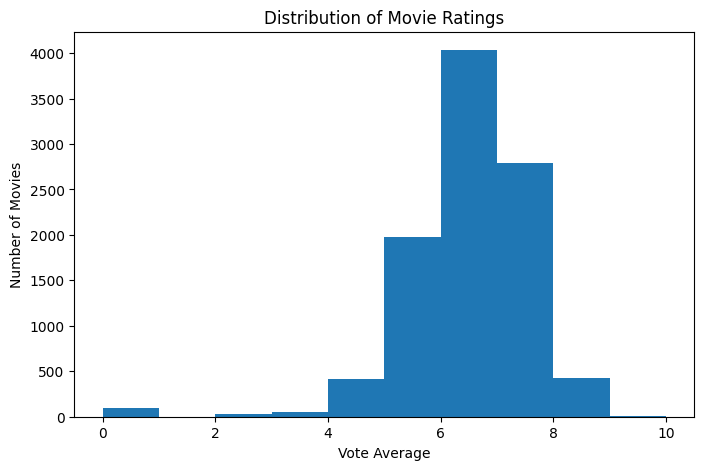

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Vote_Average'], bins=10)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")

plt.show()

In [87]:
df['Release_Date'].head()

,Release_Date
0,2021-12-15
1,2022-03-01
2,2022-02-25
3,2021-11-24
4,2021-12-22


In [88]:
df['Release_Date'].dtype

dtype('<M8[ns]')

In [89]:
df['Release_Date'].value_counts().sort_index().tail(10)

,count
Release_Date,
2022-12-16,1
2023-02-15,1
2023-03-17,1
2023-04-06,1
2023-05-03,1
2023-05-24,1
2023-06-07,1
2023-06-23,1
2023-07-26,1


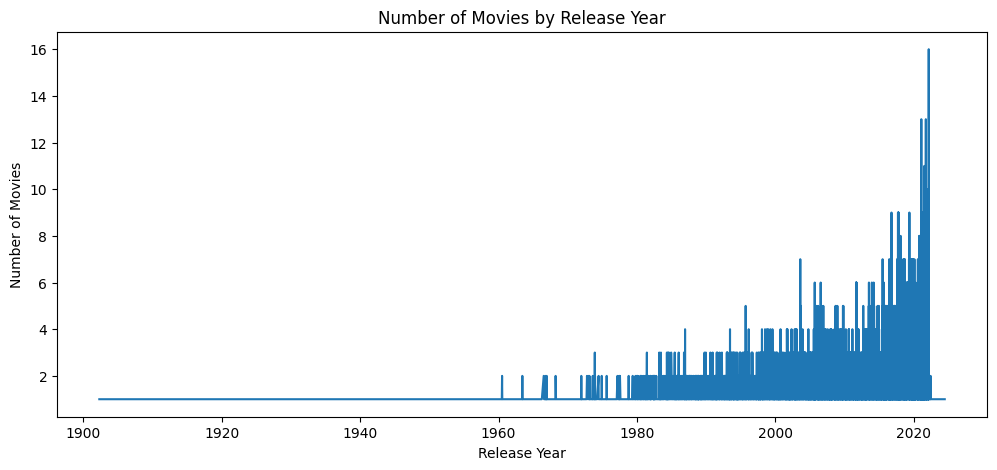

In [90]:
import matplotlib.pyplot as plt

year_counts = df['Release_Date'].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.plot(year_counts.index, year_counts.values)

plt.title("Number of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

In [91]:
most_movies_year = df['Release_Date'].value_counts().idxmax()
most_movies_count = df['Release_Date'].value_counts().max()

print("Year with most movies:", most_movies_year)
print("Number of movies:", most_movies_count)

Year with most movies: 2022-03-10 00:00:00
Number of movies: 16


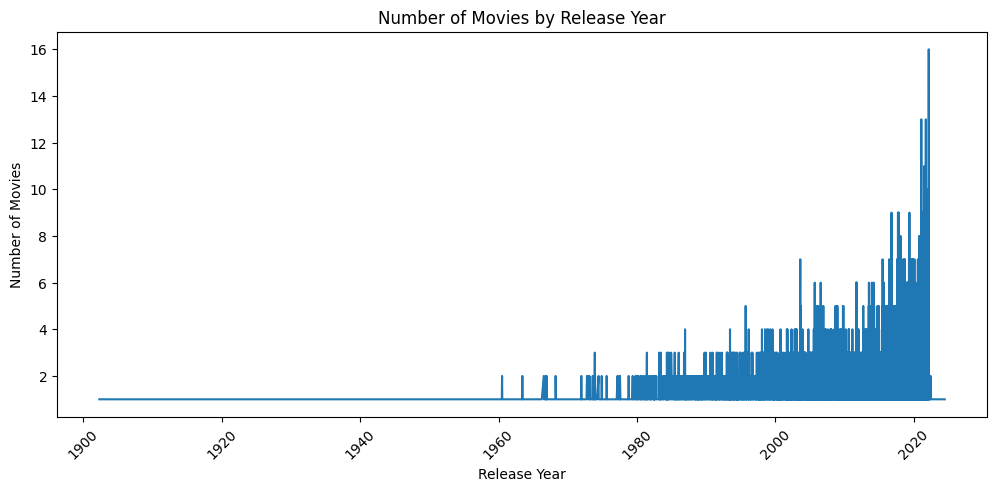

In [92]:
import matplotlib.pyplot as plt

year_counts = df['Release_Date'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)

plt.title("Number of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()


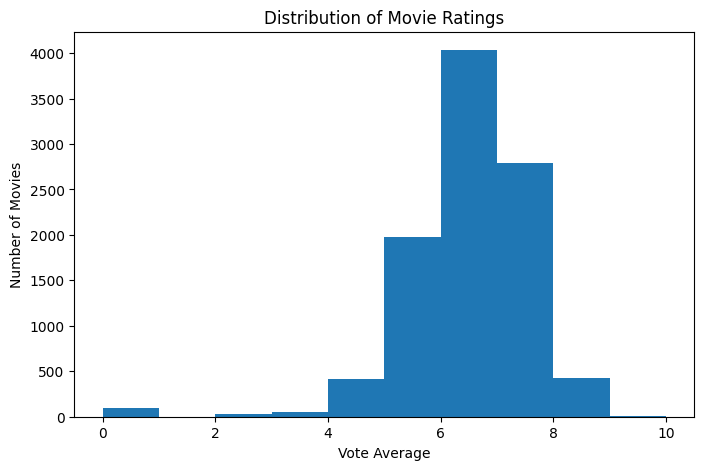

In [93]:
import matplotlib.pyplot as plt

df['Vote_Average'].plot(kind='hist', bins=10, figsize=(8,5))

plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")

plt.show()

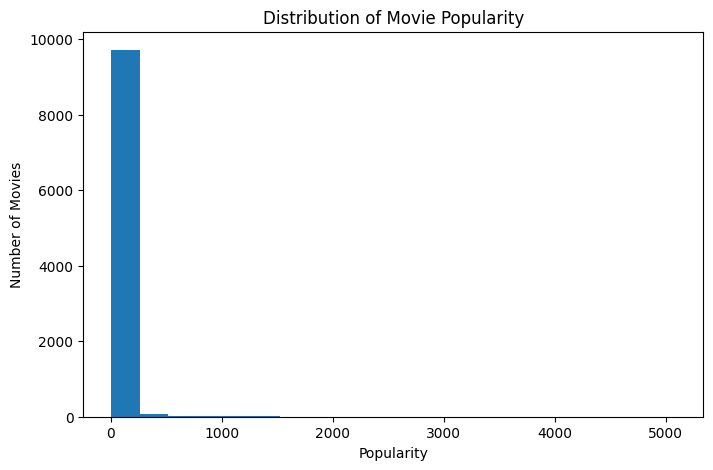

In [94]:
import matplotlib.pyplot as plt

df['Popularity'].plot(kind='hist', bins=20, figsize=(8,5))

plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")

plt.show()

In [97]:
print(df.columns.tolist())

['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url', 'Release_Year']


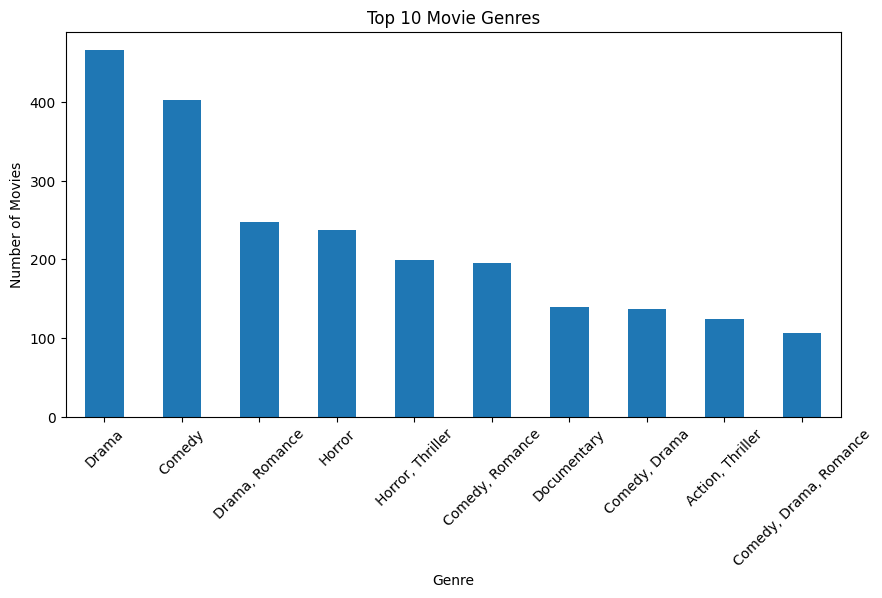

In [98]:
import matplotlib.pyplot as plt

top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

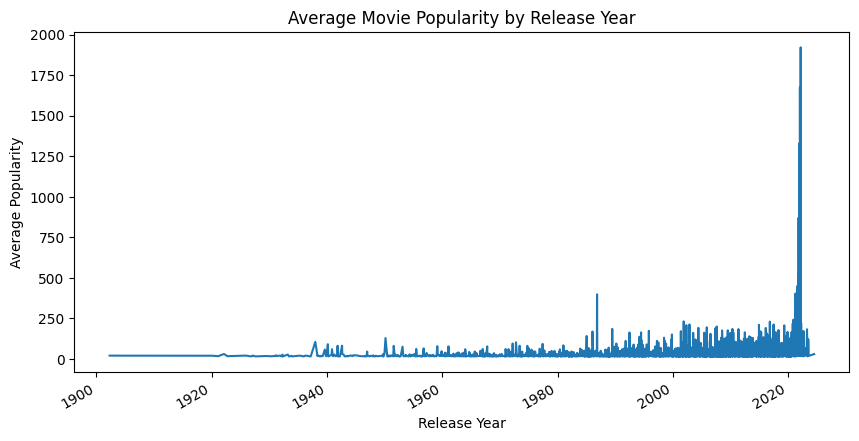

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df.groupby('Release_Date')['Popularity'].mean().plot(kind='line')

plt.title("Average Movie Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")

plt.show()

In [100]:
df['Tags'] = (
    df['Genre'].fillna('') + ' ' +
    df['Overview'].fillna('')
)

df[['Title', 'Tags']].head()

,Title,Tags
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction Peter Parke..."
1,The Batman,"Crime, Mystery, Thriller In his second year of..."
2,No Exit,Thriller Stranded at a rest stop in the mounta...
3,Encanto,"Animation, Comedy, Family, Fantasy The tale of..."
4,The King's Man,"Action, Adventure, Thriller, War As a collecti..."


In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['Tags'])

print(tfidf_matrix.shape)

(9837, 28480)


In [102]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

print(similarity.shape)

(9837, 9837)


In [103]:
indices = pd.Series(df.index, index=df['Title']).drop_duplicates()

In [104]:
def recommend_movies(title, n=10):
    if title not in indices:
        return "Movie not found"

    idx = indices[title]

    similarity_scores = list(enumerate(similarity[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_movies = similarity_scores[1:n+1]

    movie_indices = [i[0] for i in top_movies]

    return df['Title'].iloc[movie_indices].tolist()

In [105]:
recommend_movies(df['Title'].iloc[0], 10)

['Spider-Man',
 'Spider-Man Strikes Back',
 'Spider-Man',
 'Spider-Man: Homecoming',
 'Spider-Man: Far From Home',
 'Spider-Man: Into the Spider-Verse',
 'The Amazing Spider-Man 2',
 'Spider-Man 3',
 'The Amazing Spider-Man',
 '3 Days to Kill']

In [106]:
print("Movie:", df['Title'].iloc[0])
print("\nRecommended Movies:")

for i, movie in enumerate(recommend_movies(df['Title'].iloc[0], 10), 1):
    print(f"{i}. {movie}")

Movie: Spider-Man: No Way Home

Recommended Movies:
1. Spider-Man
2. Spider-Man Strikes Back
3. Spider-Man
4. Spider-Man: Homecoming
5. Spider-Man: Far From Home
6. Spider-Man: Into the Spider-Verse
7. The Amazing Spider-Man 2
8. Spider-Man 3
9. The Amazing Spider-Man
10. 3 Days to Kill


In [107]:
# Test the recommender with 5 different movies

test_movies = df['Title'].dropna().head(5).tolist()

for movie in test_movies:
    print("\nMovie:", movie)
    print("Recommendations:")
    print(recommend_movies(movie, 5))


Movie: Spider-Man: No Way Home
Recommendations:
['Spider-Man', 'Spider-Man Strikes Back', 'Spider-Man', 'Spider-Man: Homecoming', 'Spider-Man: Far From Home']

Movie: The Batman
Recommendations:
['Batman: The Long Halloween, Part Two', 'Batman: The Long Halloween, Part One', 'Batman: Return of the Caped Crusaders', 'Batman: Gotham by Gaslight', 'Batman Begins']

Movie: No Exit
Recommendations:
['Martyrs', 'A Street Cat Named Bob', 'The Tunnel', 'Traffik', '[REC]']

Movie: Encanto
Recommendations:
['Onward', 'The Nutcracker and the Four Realms', 'The Secret of the Magic Gourd', 'Scooby-Doo! Abracadabra-Doo', 'Doraemon: Nobita and the Haunts of Evil']

Movie: The King's Man
Recommendations:
['An Ordinary Man', 'Artemis Fowl', 'Midway', 'Bullet in the Head', 'Operation Chromite']


In [108]:
# Check recommendation system for a movie from the dataset

movie = df['Title'].dropna().iloc[10]

print("Selected Movie:", movie)
print("\nRecommended Movies:")

recommendations = recommend_movies(movie, 10)

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

Selected Movie: Pursuit

Recommended Movies:
1. Escape Plan: The Extractors
2. Breathless
3. S.W.A.T.: Under Siege
4. Birds of Prey (and the Fantabulous Emancipation of One Harley Quinn)
5. Savages
6. End of a Gun
7. Night Hunter
8. 16 Blocks
9. Diablo
10. Escape Plan 2: Hades


In [109]:
# Save the final dataset with Tags

df.to_csv("netflix_movies_final.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [110]:
# Final project summary

print("===== Netflix Movie Recommendation System =====")
print("Total Movies:", len(df))
print("Total Features:", len(df.columns))
print("Recommendation Method: TF-IDF + Cosine Similarity")
print("Project Completed Successfully!")

===== Netflix Movie Recommendation System =====
Total Movies: 9837
Total Features: 11
Recommendation Method: TF-IDF + Cosine Similarity
Project Completed Successfully!


In [111]:
# Final check of the recommendation system

print("Dataset Shape:", df.shape)
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Similarity Matrix Shape:", similarity.shape)
print("Recommendation System: Ready")

Dataset Shape: (9837, 11)
TF-IDF Matrix Shape: (9837, 28480)
Similarity Matrix Shape: (9837, 9837)
Recommendation System: Ready


In [112]:
# Final test with a random movie

movie = df['Title'].dropna().sample(1).iloc[0]

print("Selected Movie:", movie)
print("\nRecommended Movies:")

for i, rec in enumerate(recommend_movies(movie, 10), 1):
    print(f"{i}. {rec}")

Selected Movie: 1941

Recommended Movies:
1. The Final Countdown
2. Tora! Tora! Tora!
3. Operation Petticoat
4. The Chinese Widow
5. The Wolf of Snow Hollow
6. Wonder Woman
7. Pearl Harbor
8. Crimson Tide
9. Railroad Tigers
10. Zog and the Flying Doctors


In [113]:
# Final project files check

import os

files = [
    "netflix_movies_cleaned.csv",
    "netflix_movies_final.csv",
    "tfidf_vectorizer.pkl",
    "movie_similarity.pkl"
]

for file in files:
    print(file, "✓" if os.path.exists(file) else "✗")

netflix_movies_cleaned.csv ✓
netflix_movies_final.csv ✓
tfidf_vectorizer.pkl ✗
movie_similarity.pkl ✗


In [114]:
# Final test with a random movie

movie = df['Title'].dropna().sample(1).iloc[0]

print("Selected Movie:", movie)
print("\nRecommended Movies:")

for i, rec in enumerate(recommend_movies(movie, 10), 1):
    print(f"{i}. {rec}")

Selected Movie: Alvin and the Chipmunks Meet Frankenstein

Recommended Movies:
1. Frankenstein Meets the Wolf Man
2. Frankenstein
3. Young Frankenstein
4. Victor Frankenstein
5. I, Frankenstein
6. The Bride of Frankenstein
7. Alvin and the Chipmunks Meet the Wolfman
8. Death Race: Beyond Anarchy
9. Adventureland
10. Monster Family 2
